# Experiment 2A: SHD — Hidden-Layer Perturbation

## Overview

This notebook implements Experiment 2A from the "Beyond Beyond Rate" project.
We train a 2-hidden-layer SNN on the Spiking Heidelberg Digits (SHD) dataset
with **no perturbation** (f=0), then evaluate it by applying spike-timing
perturbation at the **output of the 1st hidden layer** instead of the input.

**Key idea:** At test time we intercept the 1st hidden layer's spike output,
replace a fraction *f* of each neuron's spikes with randomly placed spikes
(preserving spike count per neuron), and measure how downstream accuracy
degrades. This tests whether the network's *internal* representations rely
on spike timing or collapse to rate codes.

**Architecture:** Input → 128 hidden → 128 hidden → 20 output (SRMALPHA)

**Dataset variants:** whole (700 input neurons), part (224), norm (224)

A global `USE_DELAY` flag selects whether to train with learnable delays
(SGD-delay) or without (SGD).

## 1. Imports and Setup

In [70]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import slayerSNN as snn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Global Configuration

All key hyper-parameters and switches are defined here so that switching
between dataset variants or delay/no-delay mode requires editing only
this cell.

In [71]:
# =====================================================================
# Network variant: set to True for SGD-delay, False for SGD (no delay)
# =====================================================================
USE_DELAY: bool = False

# =====================================================================
# Dataset variant: "whole", "part", or "norm"
# =====================================================================
DATASET_KEY: str = "whole"

# --- Dataset configurations ---
DATASET_CONFIGS = {
    "whole": {"mat_file": "shd_data/shd_whole.mat", "input_dim": 700},
    "part":  {"mat_file": "shd_data/shd_part_new.mat", "input_dim": 224},
    "norm":  {"mat_file": "shd_data/shd_norm_new.mat", "input_dim": 224},
}

# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 200}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 10,
    "tauSr": 1,
    "tauRho": 0.1,
    "tauRef": 2,
    "scaleRef": 2,
    "scaleRho": 0.1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS: int = 128
NUM_CLASSES: int = 20
EPOCHS: int = 1000
BATCH_SIZE: int = 128
LEARNING_RATE: float = 0.1
SEED: int = 42
MAX_DELAY: int = 64
EARLY_STOP_PATIENCE: int = 300

# --- Hidden-perturbation sweep ---
F_VALUES: list[float] = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS: int = 3

# --- Derived names ---
INPUT_DIM: int = DATASET_CONFIGS[DATASET_KEY]["input_dim"]
MAT_FILE: str = DATASET_CONFIGS[DATASET_KEY]["mat_file"]
DELAY_TAG: str = "delay" if USE_DELAY else "nodelay"
MODEL_PREFIX: str = f"shd_{DATASET_KEY}_{DELAY_TAG}"

print(f"Dataset: {DATASET_KEY} | Input dim: {INPUT_DIM}")
print(f"Network mode: {'SGD-delay' if USE_DELAY else 'SGD (no delay)'}")
print(f"Model prefix: {MODEL_PREFIX}")

Dataset: whole | Input dim: 700
Network mode: SGD (no delay)
Model prefix: shd_whole_nodelay


## 3. Load SHD Dataset

Load the dense spike-train dataset from the local `.mat` file.
Each sample has shape `(num_neurons, T)` with binary spike values.
Time dimension is padded to 200 time steps to match `tSample`.

In [72]:
def load_shd_data(mat_path: str, target_T: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Load SHD dataset from a .mat file and pad time dimension.

    Args:
        mat_path: Path to the .mat file containing 'X' and 'Y'.
        target_T: Target time dimension (pad with zeros if shorter).

    Returns:
        Tuple of (X, Y) where X has shape (N, neurons, target_T).
    """
    data = loadmat(mat_path)
    X = data["X"]
    Y = data["Y"].ravel()

    n_samples, n_neurons, T = X.shape
    if T < target_T:
        padded = np.zeros((n_samples, n_neurons, target_T), dtype=X.dtype)
        padded[:, :, :T] = X
        X = padded
        print(f"Padded time dimension from {T} to {target_T}")

    print(f"Loaded {mat_path}: X={X.shape}, Y={Y.shape}, classes={len(np.unique(Y))}")
    return X, Y


X_all, Y_all = load_shd_data(MAT_FILE, target_T=SIM_PARAMS["tSample"])

Padded time dimension from 100 to 200
Loaded shd_data/shd_whole.mat: X=(9984, 700, 200), Y=(9984,), classes=20


## 4. Hidden-Layer Spike Perturbation

The core of the "Beyond Beyond Rate" approach. Given a hidden layer's binary
spike output of shape `(neurons, T)`, we randomly select a fraction `f` of
each neuron's spikes, remove them, and place the same number of spikes at
uniformly random (previously-silent) time bins. This destroys temporal
structure while preserving each neuron's spike count (i.e. the rate code).

In [73]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes.

    For every neuron, *f* of its spikes are removed from their original
    positions and placed at uniformly random empty time bins. The total
    spike count per neuron is preserved.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = no change, 1 = full shuffle).
        max_attempts: Max tries to find an empty time bin per spike.

    Returns:
        Perturbed spike train with same shape and spike counts.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        for old_time in spike_times:
            if np.random.rand() < f:
                new_train[neuron_idx, old_time] = 0
                inserted = False
                attempts = 0
                while not inserted and attempts < max_attempts:
                    attempts += 1
                    new_t = np.random.randint(0, T)
                    if new_train[neuron_idx, new_t] == 0:
                        new_train[neuron_idx, new_t] = 1
                        inserted = True
    return new_train


def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float,
) -> torch.Tensor:
    """Apply perturbation to a batch of hidden spike tensors.

    Converts to numpy, perturbs each sample, and converts back.
    Expects SLAYER's 5-D format: (batch, neurons, 1, 1, T).

    Args:
        hidden_spikes: Spike tensor of shape (B, C, 1, 1, T).
        f: Perturbation fraction.

    Returns:
        Perturbed spike tensor with same shape and device.
    """
    dev = hidden_spikes.device
    spikes_np = hidden_spikes.cpu().numpy()
    B, C, H, W, T = spikes_np.shape

    for b in range(B):
        sample = spikes_np[b, :, 0, 0, :]  # (C, T)
        spikes_np[b, :, 0, 0, :] = partial_randomize_spike_train(sample, f)

    return torch.from_numpy(spikes_np).to(dev)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to split into train / validation / test
sets. Training always uses **unperturbed** data (f=0); perturbation is applied
only at test time inside the network's forward pass.

In [74]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(
    split_range: tuple[float, float],
    total: int,
) -> np.ndarray:
    """Return index array for a given fractional range of the dataset."""
    start = int(total * split_range[0])
    end = int(total * split_range[1])
    return np.arange(start, end)


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 128,
    seed: int = 42,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data and build train/val/test DataLoaders.

    Args:
        X: Full dataset features, shape (N, neurons, T).
        Y: Full dataset labels, shape (N,).
        batch_size: Batch size for all loaders.
        seed: Random seed for train shuffle.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    N = len(Y)
    train_idx = get_split_indices(TRAIN_RANGE, N)
    val_idx = get_split_indices(VAL_RANGE, N)
    test_idx = get_split_indices(TEST_RANGE, N)

    np.random.seed(seed)
    np.random.shuffle(train_idx)

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A 2-hidden-layer SLAYER SNN matching the original SHD architecture from
the Beyond Rate codebase:

```
Input → [PSP + fc1 + spike] → (delay1) → hidden1 spikes
      → [PSP + fc2 + spike] → (delay2) → hidden2 spikes
      → [PSP + fc3 + spike] → output
```

`forward_with_hidden_perturbation` splits the forward pass at the 1st
hidden layer so we can intercept and perturb hidden spikes at test time.

In [75]:
class SHDNetwork(nn.Module):
    """2-hidden-layer SLAYER SNN for SHD classification.

    Provides two forward methods:
    - ``forward``: standard pass (used during training).
    - ``forward_with_hidden_perturbation``: intercepts 1st hidden layer
      spikes, applies perturbation, then continues (used at test time).
    """

    def __init__(
        self,
        input_dim: int,
        hidden_units: int = 128,
        num_classes: int = 20,
        use_delay: bool = True,
        max_delay: int = 64,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer
        self.use_delay = use_delay
        self.max_delay = max_delay

        # Three FC layers with weight normalisation
        self.fc1 = nn.utils.weight_norm(
            slayer.dense(input_dim, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, hidden_units), name="weight"
        )
        self.fc3 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # Optional learnable delay modules
        if use_delay:
            self.delay1 = slayer.delay(hidden_units)
            self.delay2 = slayer.delay(hidden_units)

    # -----------------------------------------------------------------
    # Forward-pass building blocks
    # -----------------------------------------------------------------
    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_hidden(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> PSP -> fc1 -> spike -> (delay1) -> hidden1 spikes."""
        x = self.slayer.spike(self.fc1(self.slayer.psp(x)))
        if self.use_delay:
            x = self.delay1(x)
        return x

    def _second_hidden_and_output(self, hidden1: torch.Tensor) -> torch.Tensor:
        """hidden1 -> PSP -> fc2 -> spike -> (delay2) -> PSP -> fc3 -> spike."""
        x = self.slayer.spike(self.fc2(self.slayer.psp(hidden1)))
        if self.use_delay:
            x = self.delay2(x)
        x = self.slayer.spike(self.fc3(self.slayer.psp(x)))
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Standard forward pass (no perturbation)."""
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)
        return self._second_hidden_and_output(hidden1)

    def forward_with_hidden_perturbation(
        self,
        x: torch.Tensor,
        f: float = 0.0,
    ) -> torch.Tensor:
        """Forward pass with perturbation applied to 1st hidden layer spikes.

        Args:
            x: Input spike trains.
            f: Fraction of hidden spikes to randomly relocate.

        Returns:
            Output spike tensor.
        """
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)

        if f > 0:
            hidden1 = perturb_hidden_batch(hidden1, f)

        return self._second_hidden_and_output(hidden1)

    def clamp_delays(self, max1: int = 64, max2: int = 64) -> None:
        """Clamp delay parameters to [0, max]."""
        if not self.use_delay:
            return
        self.delay1.delay.data.clamp_(0, max1)
        self.delay2.delay.data.clamp_(0, max2)

    def get_delays(self) -> dict[str, np.ndarray]:
        """Return current delay values as a dict."""
        delays = {}
        if self.use_delay:
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

## 7. Training Loop

Train the model on **unperturbed** data (f=0). We use SLAYER's `SpikeRate`
loss with target spike rate regions, matching the original SHD training
script. The Nadam optimiser is used with a multi-step LR schedule.
Delay clamping follows the adaptive strategy from the original code.

In [76]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility."""
    import torch.backends.cudnn as cudnn
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        cudnn.benchmark = False
        cudnn.deterministic = True
        cudnn.enabled = False


def build_loss_and_optimizer(
    net: SHDNetwork,
    lr: float = 0.1,
) -> tuple:
    """Build SpikeRate loss, Nadam optimizer, and LR scheduler.

    Args:
        net: The SHD network to optimize.
        lr: Base learning rate.

    Returns:
        Tuple of (loss_fn, optimizer, scheduler).
    """
    error_cfg = {
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {
            "error": {
                "type": "NumSpikes",
                "tgtSpikeRegion": {"start": 0, "stop": 200},
                "tgtSpikeCount": {True: 40, False: 4},
            }
        },
    }
    loss_fn = snn.spikeLoss.spikeLoss(error_cfg)
    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.1
    )
    return loss_fn, optimizer, scheduler


def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    input_dim: int,
    hidden_units: int = 128,
    num_classes: int = 20,
    use_delay: bool = True,
    max_delay: int = 64,
    epochs: int = 1000,
    lr: float = 0.1,
    seed: int = 42,
    patience: int = 300,
) -> tuple[SHDNetwork, dict]:
    """Train the SHDNetwork on unperturbed data.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        input_dim: Number of input neurons.
        hidden_units: Hidden layer size.
        num_classes: Number of output classes.
        use_delay: Whether to use learnable delays.
        max_delay: Maximum delay in time steps.
        epochs: Maximum training epochs.
        lr: Learning rate.
        seed: Random seed.
        patience: Early stopping patience.

    Returns:
        Tuple of (trained network, training log dict).
    """
    set_seed(seed)

    net = SHDNetwork(
        input_dim, hidden_units, num_classes, use_delay, max_delay
    ).to(device)
    loss_fn, optimizer, scheduler = build_loss_and_optimizer(net, lr=lr)
    loss_fn = loss_fn.to(device)

    best_val_loss = float("inf")
    best_model_state = None
    early_stop_counter = 0

    # Adaptive delay clamping state
    update1 = 0
    update2 = 0
    thea1 = max_delay
    thea2 = max_delay

    log = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "delay_mean": [],
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc="Training") as pbar:
        for epoch in range(epochs):
            # --- Train ---
            net.train()
            batch_losses = []

            for x_batch, y_batch in train_loader:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                y_batch = y_batch.to(device).long()

                target = torch.zeros(
                    (len(y_batch), num_classes, 1, 1, 1), device=device
                )
                target.scatter_(1, y_batch[:, None, None, None, None], 1.0)

                outputs = net(x_batch)
                loss = loss_fn.numSpikes(outputs, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                batch_losses.append(loss.item())
                pbar.update(1)

            # --- Adaptive delay clamping ---
            if use_delay:
                if epoch <= 250:
                    net.clamp_delays(max_delay, max_delay)
                else:
                    update1 += 1
                    update2 += 1
                    for name, param in net.named_parameters():
                        if "delay1.delay" in name and update1 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea1_val = torch.max(sorted_)
                            if sorted_[108] > (thea1_val - 5):
                                thea1 = int(thea1_val.item()) + 1
                                update1 = 0
                        elif "delay2.delay" in name and update2 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea2_val = torch.max(sorted_)
                            if sorted_[108] > (thea2_val - 5):
                                thea2 = int(thea2_val.item()) + 1
                                update2 = 0
                    net.clamp_delays(thea1, thea2)

            # --- Validate ---
            net.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch = (
                        x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                    )
                    y_batch = y_batch.to(device).long()

                    target = torch.zeros(
                        (len(y_batch), num_classes, 1, 1, 1), device=device
                    )
                    target.scatter_(
                        1, y_batch[:, None, None, None, None], 1.0
                    )

                    outputs = net(x_batch)
                    val_loss += loss_fn.numSpikes(outputs, target).item()

                    pred = snn.predict.getClass(outputs)
                    correct += (pred.cpu() == y_batch.cpu()).sum().item()
                    total += len(y_batch)

            val_loss /= max(1, len(val_loader))
            val_acc = correct / max(1, total)
            train_loss = np.mean(batch_losses)

            # Log delay statistics
            delays = net.get_delays()
            avg_delay = (
                np.mean([
                    np.mean(d) for d in delays.values() if len(d) > 0
                ])
                if delays
                else 0.0
            )

            log["epoch"].append(epoch)
            log["train_loss"].append(float(train_loss))
            log["val_loss"].append(float(val_loss))
            log["val_acc"].append(float(val_acc))
            log["delay_mean"].append(float(avg_delay))

            pbar.set_postfix(
                epoch=epoch + 1,
                train=f"{train_loss:.3f}",
                val=f"{val_loss:.3f}",
                acc=f"{val_acc:.2%}",
                delay=f"{avg_delay:.1f}",
            )
            scheduler.step()

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {
                    k: v.clone() for k, v in net.state_dict().items()
                }
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                    break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    return net, log

## 8. Testing with Hidden-Layer Perturbation

Evaluate the trained model by sweeping over perturbation levels `f`.
For each `f`, the forward pass is intercepted at the 1st hidden layer
and the spike output is perturbed before being fed to the 2nd hidden layer.

In [77]:
def test_with_hidden_perturbation(
    net: SHDNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*.

    Args:
        net: Trained SHDNetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction applied to 1st hidden layer spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
            y_batch = y_batch.to(device)

            outputs = net.forward_with_hidden_perturbation(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def run_hidden_perturbation_sweep(
    net: SHDNetwork,
    test_loader: DataLoader,
    f_values: list[float],
    num_repeats: int = 3,
) -> dict[float, dict]:
    """Sweep over perturbation levels and collect accuracy statistics.

    Each *f* is evaluated *num_repeats* times (different random seeds)
    to obtain mean and std.

    Args:
        net: Trained SHDNetwork.
        test_loader: Test DataLoader.
        f_values: List of perturbation fractions to evaluate.
        num_repeats: Number of independent evaluations per f.

    Returns:
        Dict mapping each f to {"mean", "std", "values"}.
    """
    results: dict[float, dict] = {}

    for f in f_values:
        accuracies = []
        for repeat in range(num_repeats):
            np.random.seed(SEED + repeat)
            acc = test_with_hidden_perturbation(net, test_loader, f=f)
            accuracies.append(acc)

        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        results[f] = {
            "mean": mean_acc, "std": std_acc, "values": accuracies
        }
        print(f"  f={f:.1f}:  accuracy = {mean_acc:.4f} +/- {std_acc:.4f}")

    return results

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss, validation accuracy, and delay evolution).
2. Accuracy vs. hidden-perturbation level *f* (the main result).

In [78]:
def plot_training_curves(log: dict) -> None:
    """Plot training / validation loss, accuracy, and delay evolution."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curves
    axes[0].plot(
        log["epoch"], log["train_loss"],
        "o-", label="Train loss", markersize=2,
    )
    axes[0].plot(
        log["epoch"], log["val_loss"],
        "s-", label="Val loss", markersize=2,
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Validation accuracy
    axes[1].plot(
        log["epoch"], log["val_acc"],
        "o-", color="green", markersize=2,
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Validation Accuracy")
    axes[1].grid(True, alpha=0.3)

    # Delay evolution
    if any(d != 0.0 for d in log["delay_mean"]):
        axes[2].plot(log["epoch"], log["delay_mean"], color="purple")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Mean Delay (time steps)")
        axes[2].set_title("Average Delay Over Training")
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(
            0.5, 0.5, "No delays\n(SGD mode)",
            ha="center", va="center", fontsize=14,
            transform=axes[2].transAxes,
        )
        axes[2].set_title("Delay Evolution (N/A)")

    plt.suptitle(
        f"SHD {DATASET_KEY} ({DELAY_TAG}) Training Curves", fontsize=14
    )
    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(
    results: dict[float, dict],
) -> None:
    """Plot accuracy vs hidden perturbation level f."""
    f_vals = sorted(results.keys())
    means = [results[f]["mean"] for f in f_vals]
    stds = [results[f]["std"] for f in f_vals]

    color = "tab:orange" if USE_DELAY else "tab:blue"
    label = (
        f"SGD-delay ({DATASET_KEY})"
        if USE_DELAY
        else f"SGD ({DATASET_KEY})"
    )

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        f_vals, means, yerr=stds, fmt="o-",
        capsize=5, capthick=2, color=color, label=label,
    )
    plt.xlabel("Hidden Perturbation Level (f)")
    plt.ylabel("Test Accuracy")
    plt.title(
        f"Exp 2A: SHD {DATASET_KEY} "
        f"\u2014 Accuracy vs Hidden-Layer Perturbation ({DELAY_TAG})"
    )
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean, std in zip(f_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    fig_path = (
        f"log/shd_{DATASET_KEY}_{DELAY_TAG}_hidden_perturbation.png"
    )
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {fig_path}")

## 10. Run: Train the Model (f=0)

Train on unperturbed data. The best model (by validation loss) is saved
to disk for later reuse.

In [79]:
# Build data loaders (unperturbed)
train_loader, val_loader, test_loader = build_dataloaders(
    X_all, Y_all, batch_size=BATCH_SIZE, seed=SEED
)

# Train
net, training_log = train_model(
    train_loader=train_loader,
    val_loader=val_loader,
    input_dim=INPUT_DIM,
    hidden_units=HIDDEN_UNITS,
    num_classes=NUM_CLASSES,
    use_delay=USE_DELAY,
    max_delay=MAX_DELAY,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    seed=SEED,
    patience=EARLY_STOP_PATIENCE,
)

# Quick sanity check: accuracy on clean test set (f=0)
clean_acc = test_with_hidden_perturbation(net, test_loader, f=0.0)
print(f"\nClean test accuracy (f=0): {clean_acc:.4f}")

# Save trained model
os.makedirs("data", exist_ok=True)
model_path = f"data/{MODEL_PREFIX}_trained.pt"
torch.save(net.state_dict(), model_path)
print(f"Model saved to {model_path}")

Train: 5990 | Val: 1498 | Test: 1497


Training: 100%|██████████| 47000/47000 [1:22:16<00:00,  9.52it/s, acc=67.29%, delay=0.0, epoch=1000, train=247.474, val=285.026]



Clean test accuracy (f=0): 0.5558
Model saved to data/shd_whole_nodelay_trained.pt


## 11. Plot Training Curves

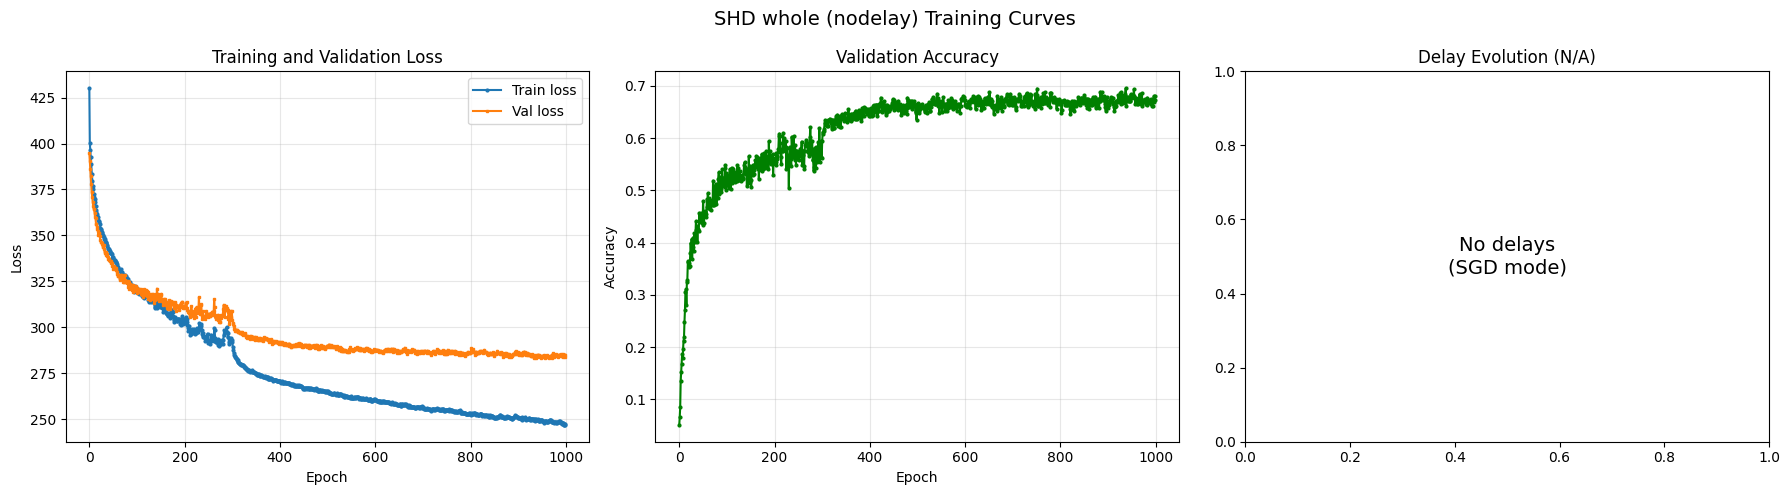

In [80]:
plot_training_curves(training_log)

## 12. Hidden-Perturbation Sweep

Apply perturbation at the 1st hidden layer output for
f in {0, 0.2, 0.4, 0.6, 0.8, 1.0}.
Each level is repeated 3 times with different random seeds to get
error bars.

**Interpretation guide:**
- If accuracy degrades with increasing f: the hidden layer preserves
  temporal structure.
- If accuracy stays flat: the hidden layer has collapsed temporal info
  to a rate code.
- Compare SGD-delay vs SGD to see if delays lead to richer internal
  temporal codes.

In [81]:
print(
    f"=== Hidden-Layer Perturbation Sweep "
    f"(SHD {DATASET_KEY}, {DELAY_TAG}) ==="
)
sweep_results = run_hidden_perturbation_sweep(
    net, test_loader, f_values=F_VALUES, num_repeats=NUM_REPEATS
)

=== Hidden-Layer Perturbation Sweep (SHD whole, nodelay) ===
  f=0.0:  accuracy = 0.5558 +/- 0.0000
  f=0.2:  accuracy = 0.2547 +/- 0.0060
  f=0.4:  accuracy = 0.2383 +/- 0.0055
  f=0.6:  accuracy = 0.2251 +/- 0.0036
  f=0.8:  accuracy = 0.2202 +/- 0.0030
  f=1.0:  accuracy = 0.2106 +/- 0.0030


## 13. Plot Results

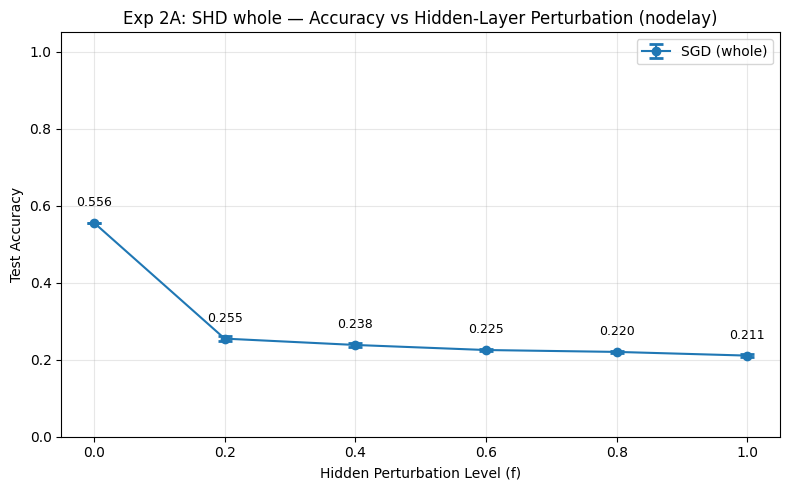

Figure saved to log/shd_whole_nodelay_hidden_perturbation.png


In [82]:
plot_hidden_perturbation_curve(sweep_results)

## 14. Save Results

Save the sweep results and training log to JSON for later comparison
across dataset variants and delay/no-delay modes.

In [83]:
# Convert results to JSON-serialisable format
results_serialisable = {
    str(f_val): {
        "mean": float(data["mean"]),
        "std": float(data["std"]),
        "values": [float(v) for v in data["values"]],
    }
    for f_val, data in sweep_results.items()
}

os.makedirs("log", exist_ok=True)
results_path = (
    f"log/shd_{DATASET_KEY}_{DELAY_TAG}_hidden_perturbation_results.json"
)
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Results saved to {results_path}")

# Save training log
log_path = f"log/shd_{DATASET_KEY}_{DELAY_TAG}_training_log.json"
training_log_serialisable = {
    k: [float(v) for v in vals] if isinstance(vals, list) else vals
    for k, vals in training_log.items()
}
with open(log_path, "w") as fp:
    json.dump(training_log_serialisable, fp, indent=2)
print(f"Training log saved to {log_path}")

Results saved to log/shd_whole_nodelay_hidden_perturbation_results.json
Training log saved to log/shd_whole_nodelay_training_log.json


## 15. Model Analysis

Print delay statistics and weight statistics for inspection.

In [84]:
print(
    f"=== Learned Parameter Analysis "
    f"(SHD {DATASET_KEY}, {DELAY_TAG}) ==="
)

# Delay statistics
delays = net.get_delays()
if delays:
    for delay_name, delay_values in delays.items():
        if len(delay_values) > 0:
            print(
                f"Learned {delay_name}: "
                f"mean={np.mean(delay_values):.2f}, "
                f"std={np.std(delay_values):.2f}, "
                f"min={np.min(delay_values):.2f}, "
                f"max={np.max(delay_values):.2f}"
            )
else:
    print("No delays (SGD mode)")

# Weight statistics per layer
for name, param in net.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"{name}: mean={w.mean().item():.4f}, "
            f"std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )

=== Learned Parameter Analysis (SHD whole, nodelay) ===
No delays (SGD mode)
fc1.weight_g: mean=39.7592, std=28.4301, shape=[128, 1, 1, 1, 1]
fc1.weight_v: mean=-0.8521, std=10.7609, shape=[128, 700, 1, 1, 1]
fc2.weight_g: mean=53.7688, std=66.7980, shape=[128, 1, 1, 1, 1]
fc2.weight_v: mean=-0.2353, std=6.3544, shape=[128, 128, 1, 1, 1]
fc3.weight_g: mean=197.5736, std=40.3379, shape=[20, 1, 1, 1, 1]
fc3.weight_v: mean=-0.4522, std=7.4275, shape=[20, 128, 1, 1, 1]
